# 04-2. TensorFlow 저수준 학습 원리

4장에서 우리는 Keras의 `fit()`으로 모델을 학습시켰다.

이번 노트북에서는 `fit()` 안에서 일어나는 일을 직접 풀어본다.

목표는 하나다.

```text
y = 2x + 1
```

이 규칙을 모델이 `w`와 `b`를 고치면서 배우게 만든다.


In [1]:

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# 실습을 다시 실행해도 비슷한 결과가 나오도록 난수 seed를 고정한다.
# 이번 예제는 난수를 거의 쓰지 않지만, 습관처럼 고정해두면 좋다.
tf.random.set_seed(42)
np.random.seed(42)


In [2]:

# x_data는 모델에게 보여줄 입력값이다.
# y_data는 각 입력에 대한 정답이다.
#
# 규칙은 y = 2x + 1 이다.
# x=0 -> y=1
# x=1 -> y=3
# x=2 -> y=5
# x=3 -> y=7
# x=4 -> y=9
x_data = np.array([0, 1, 2, 3, 4], dtype=np.float32)
y_data = np.array([1, 3, 5, 7, 9], dtype=np.float32)

print("입력 x:", x_data)
print("정답 y:", y_data)


입력 x: [0. 1. 2. 3. 4.]
정답 y: [1. 3. 5. 7. 9.]


In [3]:

# w와 b는 모델이 학습하면서 직접 바꿀 값이다.
# TensorFlow에서 학습 중 바뀌어야 하는 값은 tf.Variable로 만든다.
#
# 처음에는 아무것도 모른다고 가정하고 둘 다 0에서 시작한다.
w = tf.Variable(0.0)
b = tf.Variable(0.0)

def predict(x):
    # 모델의 예측식이다.
    # 현재 w와 b를 사용해 y = w*x + b 형태로 예측한다.
    return w * x + b

def mse_loss(y_true, y_pred):
    # MSE는 Mean Squared Error의 줄임말이다.
    # 정답과 예측의 차이를 제곱한 뒤 평균을 낸다.
    return tf.reduce_mean(tf.square(y_true - y_pred))

first_pred = predict(x_data)
first_loss = mse_loss(y_data, first_pred)

print("처음 w:", w.numpy())
print("처음 b:", b.numpy())
print("처음 예측:", first_pred.numpy())
print("처음 loss:", first_loss.numpy())


처음 w: 0.0
처음 b: 0.0
처음 예측: [0. 0. 0. 0. 0.]
처음 loss: 33.0


## 한 번의 학습이 어떻게 생겼는지 보기

학습을 길게 반복하기 전에, 딱 한 번만 해보자.

한 번의 학습은 다음 순서다.

```text
1. 현재 w와 b로 예측한다.
2. loss를 계산한다.
3. GradientTape로 w와 b에 대한 gradient를 계산한다.
4. optimizer가 w와 b를 조금 수정한다.
```


In [4]:

# optimizer는 gradient를 보고 w와 b를 실제로 수정하는 도구다.
# SGD는 가장 기본적인 optimizer 중 하나다.
# learning_rate는 한 번에 얼마나 크게 움직일지 정하는 값이다.
optimizer = tf.optimizers.SGD(learning_rate=0.01)

print("업데이트 전")
print("w:", w.numpy(), "b:", b.numpy())

with tf.GradientTape() as tape:
    # GradientTape 안에서 예측과 loss 계산을 한다.
    # TensorFlow는 이 계산 과정을 기록해둔다.
    y_pred = predict(x_data)
    loss = mse_loss(y_data, y_pred)

# loss를 줄이기 위해 w와 b를 어느 방향으로 움직여야 하는지 계산한다.
grad_w, grad_b = tape.gradient(loss, [w, b])

print("\n계산된 gradient")
print("w에 대한 gradient:", grad_w.numpy())
print("b에 대한 gradient:", grad_b.numpy())

# 계산된 gradient를 w와 b에 적용한다.
optimizer.apply_gradients([(grad_w, w), (grad_b, b)])

print("\n업데이트 후")
print("w:", w.numpy(), "b:", b.numpy())


업데이트 전
w: 0.0 b: 0.0

계산된 gradient
w에 대한 gradient: -28.0
b에 대한 gradient: -10.0

업데이트 후
w: 0.28 b: 0.099999994


## 여러 번 반복해서 학습하기

한 번 수정했다고 바로 정답이 되지는 않는다.

그래서 같은 과정을 여러 번 반복한다.
Keras의 `fit(epochs=...)`가 해주던 반복을 여기서는 직접 `for`문으로 작성한다.


In [5]:

# 위 셀에서 이미 한 번 업데이트했으므로, 공정하게 다시 0에서 시작한다.
w = tf.Variable(0.0)
b = tf.Variable(0.0)
optimizer = tf.optimizers.SGD(learning_rate=0.01)

loss_history = []
w_history = []
b_history = []

for step in range(200):
    with tf.GradientTape() as tape:
        y_pred = predict(x_data)
        loss = mse_loss(y_data, y_pred)

    gradients = tape.gradient(loss, [w, b])
    optimizer.apply_gradients(zip(gradients, [w, b]))

    loss_history.append(float(loss.numpy()))
    w_history.append(float(w.numpy()))
    b_history.append(float(b.numpy()))

    if step % 40 == 0:
        print(f"step={step:3d} | loss={loss.numpy():.4f} | w={w.numpy():.4f} | b={b.numpy():.4f}")

print("\n최종 결과")
print("w:", w.numpy())
print("b:", b.numpy())
print("마지막 loss:", loss_history[-1])


step=  0 | loss=33.0000 | w=0.2800 | b=0.1000


step= 40 | loss=0.0150 | w=2.0672 | b=0.7901


step= 80 | loss=0.0091 | w=2.0574 | b=0.8364


step=120 | loss=0.0056 | w=2.0452 | b=0.8712


step=160 | loss=0.0035 | w=2.0356 | b=0.8986

최종 결과
w: 2.0281515
b: 0.9197465
마지막 loss: 0.0021846441086381674


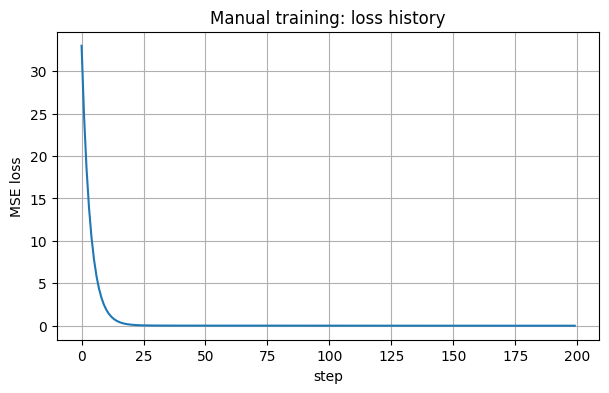

In [6]:

# loss가 줄어드는지 그래프로 확인한다.
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.title("Manual training: loss history")
plt.xlabel("step")
plt.ylabel("MSE loss")
plt.grid(True)
plt.show()


In [7]:

# 학습된 w와 b로 새로운 값을 예측해본다.
# y = 2x + 1 규칙에서 x=5이면 정답은 11이다.
new_x = np.array([5], dtype=np.float32)
new_y = predict(new_x)

print("x=5일 때 모델 예측:", new_y.numpy()[0])
print("x=5일 때 정답 규칙의 값:", 11)


x=5일 때 모델 예측: 11.060504
x=5일 때 정답 규칙의 값: 11


## Keras의 fit()과 비교하기

이제 같은 문제를 Keras로 다시 작성한다.

아래 코드는 4장에서 배운 흐름이다.
차이는 이제 우리가 `fit()` 안쪽에서 무슨 일이 일어나는지 조금 더 알고 있다는 점이다.


In [8]:

from keras.models import Sequential
from keras.layers import Input, Dense
from keras.optimizers import SGD

# Keras Dense 층은 입력을 2차원 형태로 받는 것이 안전하다.
# 모양: (샘플 수, 특성 수)
x_data_2d = x_data.reshape(-1, 1)
y_data_2d = y_data.reshape(-1, 1)

keras_model = Sequential([
    Input(shape=(1,)),
    Dense(1)
])

keras_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="mse",
)

history = keras_model.fit(
    x_data_2d,
    y_data_2d,
    epochs=200,
    verbose=0,
)

print("Keras 학습 완료")
print("마지막 loss:", history.history["loss"][-1])


Keras 학습 완료
마지막 loss: 0.0012511330423876643


In [9]:

# Keras 모델 안의 Dense 층도 결국 w와 b를 가지고 있다.
# get_weights()로 그 값을 확인할 수 있다.
dense_layer = keras_model.layers[0]
keras_w, keras_b = dense_layer.get_weights()

print("Keras가 학습한 w:", keras_w[0][0])
print("Keras가 학습한 b:", keras_b[0])

keras_pred = keras_model.predict(np.array([[5]], dtype=np.float32), verbose=0)
print("Keras 모델의 x=5 예측:", keras_pred[0][0])


Keras가 학습한 w: 2.0213041
Keras가 학습한 b: 0.9392668
Keras 모델의 x=5 예측: 11.045788


## 정리

이번 노트북에서 직접 확인한 내용은 다음과 같다.

```text
Keras의 fit() 안쪽에서는
예측 -> loss 계산 -> gradient 계산 -> w와 b 수정
이 과정이 반복된다.
```

앞으로는 `fit()`을 볼 때 단순히 "학습 버튼"이라고만 생각하지 말고,
모델 내부 숫자가 loss를 줄이는 방향으로 조금씩 바뀌는 장면을 떠올리면 된다.
